In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (matthews_corrcoef, precision_score, recall_score,
                             roc_auc_score, balanced_accuracy_score, f1_score,
                             confusion_matrix)
from imblearn.metrics import specificity_score
from sklearn.model_selection import StratifiedGroupKFold

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/yangxinzhandu/model-dataset-cleaned-v2/model_dataset_cleaned_V2.parquet')
df

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,pdb_id,position,residue,isbinding,esm_0,esm_1,esm_2,esm_3,esm_4,esm_5,...,esm_950,esm_951,esm_952,esm_953,esm_954,esm_955,esm_956,esm_957,esm_958,esm_959
0,19hc,1,A,0,-0.002398,-0.024979,0.074219,-0.044952,-0.045349,-0.006565,...,0.046600,-0.013107,0.058655,-0.051758,-0.007534,0.003609,-0.033173,0.028549,0.004845,0.027954
1,19hc,2,A,0,0.003937,-0.031982,0.018906,0.000515,-0.024185,0.026901,...,0.034302,-0.004459,0.019470,-0.045044,0.027008,0.005669,-0.000955,0.011276,0.017517,0.000127
2,19hc,3,L,0,0.005684,0.024200,-0.018204,0.007195,-0.013359,-0.000211,...,0.037079,-0.007141,0.027267,-0.023529,0.012054,0.004250,-0.007973,-0.009872,-0.004543,-0.002783
3,19hc,4,E,0,-0.017075,-0.008232,0.000607,-0.006042,0.013466,0.019470,...,0.023087,-0.014687,0.034241,-0.030823,0.015129,-0.004723,-0.030228,0.010147,-0.008209,0.001219
4,19hc,5,P,0,-0.008476,-0.011284,0.004116,-0.016678,0.016052,0.024277,...,0.019852,-0.002798,0.023788,-0.029678,0.011444,0.027283,-0.007698,0.018860,0.010880,0.014275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688026,9v14,236,Q,0,-0.016083,-0.010757,-0.018021,-0.014442,0.011795,0.001248,...,0.021149,-0.017059,0.017670,-0.042450,-0.015854,0.013161,-0.014511,0.005836,-0.029739,-0.047607
1688027,9v14,237,A,0,-0.006382,0.027481,0.033508,-0.006252,0.011955,0.036713,...,0.004532,0.024261,0.001671,-0.017700,0.037170,-0.049927,0.020889,0.060577,-0.037018,-0.044678
1688028,9v14,238,L,0,0.006989,-0.003809,-0.031464,0.016586,0.016632,0.006069,...,-0.004639,0.017639,-0.014305,-0.057739,0.015976,-0.027908,0.003632,0.006199,-0.038788,-0.026947
1688029,9v14,239,K,0,-0.014893,-0.004726,0.045380,-0.004608,0.031891,-0.015793,...,-0.026932,-0.043762,0.009468,-0.040802,0.019211,-0.026535,0.023193,0.021988,0.021866,0.018417


In [3]:
x = df.drop(columns=['pdb_id', 'position', 'residue', 'isbinding'])
y = df['isbinding']
groups = df['pdb_id']

In [5]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in sgkf.split(x, y, groups):
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1345485, 960), (1345485,), (342546, 960), (342546,))

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=3.0, alpha=0.50):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.exp(-bce)
        loss  = self.alpha * (1 - probs) ** self.gamma * bce
        return loss.mean()

In [7]:
class ResidueDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=960):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

In [11]:
def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_true  = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            probs   = torch.sigmoid(model(x_batch)).cpu().numpy()
            all_probs.extend(probs)
            all_true.extend(y_batch.numpy())

    all_probs = np.array(all_probs)
    all_true  = np.array(all_true)

    thresholds = np.linspace(0.01, 0.99, 200)
    mccs       = [matthews_corrcoef(all_true, all_probs >= t) for t in thresholds]
    best_t     = thresholds[np.argmax(mccs)]
    all_preds  = (all_probs >= best_t).astype(int)

    return all_probs, all_preds, all_true, best_t, max(mccs)

In [9]:
train_dataset = ResidueDataset(x_train, y_train)
test_dataset  = ResidueDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

In [10]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = MLP(input_dim=960).to(device)
criterion = FocalLoss(gamma=3.0, alpha=0.50)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)

In [12]:
EPOCHS       = 50
PATIENCE     = 5
best_mcc     = 0
wait         = 0
best_weights = None
history      = {'train_loss': [], 'val_mcc': []}

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    _, _, _, best_t, val_mcc = evaluate(model, test_loader)
    scheduler.step(val_mcc)

    history['train_loss'].append(avg_loss)
    history['val_mcc'].append(val_mcc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Val MCC: {val_mcc:.4f} | Threshold: {best_t:.3f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_mcc > best_mcc:
        best_mcc     = val_mcc
        best_weights = copy.deepcopy(model.state_dict())
        wait         = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} — best MCC: {best_mcc:.4f}")
            break

model.load_state_dict(best_weights)
print(f"\nRestored best weights with MCC: {best_mcc:.4f}")

Epoch 1/50 | Loss: 0.0074 | Val MCC: 0.4866 | Threshold: 0.429 | LR: 0.001000
Epoch 2/50 | Loss: 0.0065 | Val MCC: 0.5139 | Threshold: 0.419 | LR: 0.001000
Epoch 3/50 | Loss: 0.0061 | Val MCC: 0.5295 | Threshold: 0.419 | LR: 0.001000
Epoch 4/50 | Loss: 0.0056 | Val MCC: 0.5492 | Threshold: 0.453 | LR: 0.001000
Epoch 5/50 | Loss: 0.0052 | Val MCC: 0.5646 | Threshold: 0.448 | LR: 0.001000
Epoch 6/50 | Loss: 0.0049 | Val MCC: 0.5761 | Threshold: 0.453 | LR: 0.001000
Epoch 7/50 | Loss: 0.0046 | Val MCC: 0.5821 | Threshold: 0.434 | LR: 0.001000
Epoch 8/50 | Loss: 0.0043 | Val MCC: 0.5859 | Threshold: 0.448 | LR: 0.001000
Epoch 9/50 | Loss: 0.0041 | Val MCC: 0.5873 | Threshold: 0.458 | LR: 0.001000
Epoch 10/50 | Loss: 0.0039 | Val MCC: 0.5950 | Threshold: 0.458 | LR: 0.001000
Epoch 11/50 | Loss: 0.0037 | Val MCC: 0.5916 | Threshold: 0.453 | LR: 0.001000
Epoch 12/50 | Loss: 0.0036 | Val MCC: 0.5950 | Threshold: 0.468 | LR: 0.001000
Epoch 13/50 | Loss: 0.0035 | Val MCC: 0.5954 | Threshold: 0.4

In [15]:
all_probs, all_preds, all_true, best_t, _ = evaluate(model, test_loader)

print(f"\nThreshold:         {best_t:.3f}")
print(f"MCC:               {matthews_corrcoef(all_true, all_preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(all_true, all_preds):.4f}")
print(f"ROC AUC:           {roc_auc_score(all_true, all_probs):.4f}")
print(f"F1 Weighted:       {f1_score(all_true, all_preds, average='weighted'):.4f}")
print(f"Precision:         {precision_score(all_true, all_preds, zero_division=0):.4f}")
print(f"Recall:            {recall_score(all_true, all_preds):.4f}")
print(f"Specificity:       {specificity_score(all_true, all_preds, pos_label=1, average='binary'):.4f}")


Threshold:         0.448
MCC:               0.6232
Balanced Accuracy: 0.8081
ROC AUC:           0.9586
F1 Weighted:       0.9720
Precision:         0.6453
Recall:            0.6301
Specificity:       0.9860


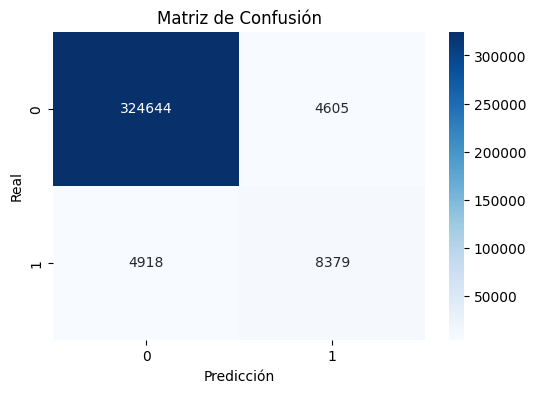

In [17]:
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
torch.save(model.state_dict(), "model.pth")